# ⚡ Wickless Candle Strategy v2 — Single Timeframe
**Architecture:**
- Single timeframe for both trend and entry (default: 15m)
- Trend = Structural CHoCH (Change of Character) via swing high/low breaks
- Trend strength = ATR slope between consecutive swing pivots
- Entry = Shaved Bottom (bullish) or Shaved Top (bearish) at candle close
- SL = Nearest swing low below entry (long) / swing high above entry (short)
- TP = Fixed RR from SL distance

**Definitions:**
- Swing Low: 3-candle pattern where middle candle's LOW < both neighbours
- Swing High: 3-candle pattern where middle candle's HIGH > both neighbours
- CHoCH Up: price breaks above last swing high AND forms a higher low → BULLISH
- CHoCH Down: price breaks below last swing low AND forms a lower high → BEARISH
- Shaved Bottom: close > open AND low == open (zero bottom wick)
- Shaved Top: close < open AND high == open (zero top wick)

In [3]:
%pip install yfinance
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.

     ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
     -- ---------------------------------- 20.5/294.9 kB 320.0 kB/s eta 0:00:01
     ------ ------------------------------ 51.2/294.9 kB 435.7 kB/s eta 0:00:01
     ----------- ------------------------- 92.2/294.9 kB 655.4 kB/s eta 0:00:01
     -------------------------- ----------- 204.8/294.9 kB 1.0 MB/s eta 0:00:01
     -------------------------------------- 294.9/294.9 kB 1.3 MB/s eta 0:00:00



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import subprocess, sys

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# scipy stats fallback
try:
    from scipy import stats as _stats
    spearmanr   = _stats.spearmanr
    ttest_1samp = _stats.ttest_1samp
except ImportError:
    def spearmanr(x, y):
        x, y = np.array(x), np.array(y)
        n = len(x)
        rx = np.argsort(np.argsort(x)).astype(float)
        ry = np.argsort(np.argsort(y)).astype(float)
        d2 = np.sum((rx - ry)**2)
        rho = 1 - (6*d2)/(n*(n**2-1))
        t  = rho * np.sqrt((n-2)/(1-rho**2+1e-12))
        from math import erfc, sqrt
        p = 2*(1-0.5*erfc(-abs(t)/sqrt(2)))
        return rho, p
    def ttest_1samp(a, popmean):
        a = np.array(a); n = len(a)
        t = (np.mean(a)-popmean)/(np.std(a,ddof=1)/np.sqrt(n)+1e-12)
        from math import erfc, sqrt
        p = 2*(1-0.5*erfc(-abs(t)/sqrt(2)))
        return t, p

plt.style.use("dark_background")
pd.set_option("display.float_format", "{:.4f}".format)
print("✅ Imports OK")

✅ Imports OK


---
## Cell 2 — ⚙️ Parameters (Edit Here)

In [83]:
# ══════════════════════════════════════════════════════════════════════════════
#                     ⚙️  STRATEGY PARAMETERS
# ══════════════════════════════════════════════════════════════════════════════

# ── Data source ───────────────────────────────────────────────────────────────
USE_LOCAL_DATA          = True
LOCAL_DATA_PATH         = "C:/Users/ratul/Downloads/Market Data/BTCUSDT-1m-2025.csv"
LOCAL_DATA_DATETIME_COL = "open_time"   # datetime column in CSV

SYMBOL     = "BTC-USD"        # yfinance symbol (used if USE_LOCAL_DATA=False)
START_DATE = "2025-01-01"
END_DATE   = "2025-12-31"

# ── Timeframe ─────────────────────────────────────────────────────────────────
# Both trend detection AND wickless candle detection use this single TF.
TIMEFRAME = "1h"   # options: "1m","5m","15m","30m","1h","4h","1d"

# ── Wickless candle definition ────────────────────────────────────────────────
# 0 = strict (low must exactly equal open for shaved bottom, etc.)
# Increase slightly (e.g. 1.0 USD) to allow a few ticks of tolerance
WICK_TOLERANCE = 0.0   # USD

# ── Displacement filter (optional, off by default) ────────────────────────────
USE_DISPLACEMENT       = True
DISPLACEMENT_THRESHOLD = 0.80   # B2R = |close-open|/(high-low) >= threshold

# ── Swing structure parameters ────────────────────────────────────────────────
# Swing confirmation: 3-candle pattern. No parameter needed — always 3 candles.
# CHoCH requires: BOS (break of structure) + confirmation of higher low / lower high
CHOCH_CONFIRM_BARS = 5   # bars after BOS to look for HL (bull) or LH (bear) confirmation
                           # if no confirmation within this window, BOS is not promoted to CHoCH

# ── Trend strength: ATR slope ─────────────────────────────────────────────────
# Compares slope between last 2 swing pivots vs prior 2 swing pivots
# If recent slope < prior slope → trend is WEAKENING → trades flagged
# Requires at least 3 confirmed swing pivots of the same type to calculate
ENABLE_TREND_STRENGTH = True   # False = ignore slope analysis, trade all signals

# ── Stop loss ─────────────────────────────────────────────────────────────────
ATR_PERIOD           = 14     # ATR period (used for fallback SL only)
ATR_SL_FALLBACK_MULT = 1.5    # fallback SL multiplier if no swing level found
# Primary SL = nearest swing low below entry (long) / swing high above entry (short)

# ── Take profit ───────────────────────────────────────────────────────────────
RR_RATIO          = 1.5
USE_TRAILING_STOP = False
TRAILING_ATR_MULT = 2.0

# ── Position sizing & risk ────────────────────────────────────────────────────
INITIAL_CAPITAL    = 10_000
RISK_PER_TRADE_PCT = 1.0     # % of capital risked per trade
COMMISSION_PCT     = 0.05    # per side (5bps)
MAX_TRADES_PER_DAY = 2       # hard cap
RUIN_GUARD_PCT     = 10.0    # stop trading below this % of initial capital

# ── Display ───────────────────────────────────────────────────────────────────
SHOW_TRADE_LOG   = True
MAX_LOG_ROWS     = 50

print(f"⚙️  Parameters loaded.")
print(f"   Timeframe      : {TIMEFRAME}")
print(f"   Wick tolerance : {WICK_TOLERANCE} USD")
print(f"   Displacement   : {'ON @ ' + str(DISPLACEMENT_THRESHOLD) if USE_DISPLACEMENT else 'OFF'}")
print(f"   CHoCH confirm  : {CHOCH_CONFIRM_BARS} bars")
print(f"   Trend strength : {'ON' if ENABLE_TREND_STRENGTH else 'OFF'}")
print(f"   RR             : {RR_RATIO}:1  |  Trailing: {USE_TRAILING_STOP}")

⚙️  Parameters loaded.
   Timeframe      : 1h
   Wick tolerance : 0.0 USD
   Displacement   : ON @ 0.8
   CHoCH confirm  : 5 bars
   Trend strength : ON
   RR             : 1.5:1  |  Trailing: False


---
## Cell 3 — Data Loading

In [84]:
TF_RESAMPLE = {
    "1m":"1min","5m":"5min","15m":"15min","30m":"30min",
    "1h":"1h","4h":"4h","1d":"1D"
}

def resample_ohlcv(df, rule):
    return df.resample(rule).agg(
        {"Open":"first","High":"max","Low":"min","Close":"last","Volume":"sum"}
    ).dropna()

if USE_LOCAL_DATA:
    print(f"📂 Loading {LOCAL_DATA_PATH}")
    df_raw = pd.read_csv(LOCAL_DATA_PATH)
    df_raw[LOCAL_DATA_DATETIME_COL] = pd.to_datetime(
        df_raw[LOCAL_DATA_DATETIME_COL], unit="ms", utc=True)
    df_raw = df_raw.set_index(LOCAL_DATA_DATETIME_COL)
    df_raw.columns = [c.strip().title() for c in df_raw.columns]
    df_raw = df_raw[["Open","High","Low","Close","Volume"]]
else:
    print(f"🌐 Fetching {SYMBOL} from yfinance")
    df_raw = yf.download(SYMBOL, start=START_DATE, end=END_DATE,
                         interval="1m", auto_adjust=True, progress=False)
    if isinstance(df_raw.columns, pd.MultiIndex):
        df_raw.columns = df_raw.columns.droplevel(1)
    df_raw.index = pd.to_datetime(df_raw.index, utc=True)

# Resample to chosen TF
rule = TF_RESAMPLE.get(TIMEFRAME, TIMEFRAME)
df = resample_ohlcv(df_raw, rule)

print(f"✅ {TIMEFRAME} bars: {len(df):,}  |  {df.index[0]} → {df.index[-1]}")
df.tail(3)

📂 Loading C:/Users/ratul/Downloads/Market Data/BTCUSDT-1m-2025.csv
✅ 1h bars: 8,760  |  2025-01-01 00:00:00+00:00 → 2025-12-31 23:00:00+00:00


,Open,High,Low,Close,Volume
open_time,,,,,
2025-12-31 21:00:00+00:00,87629.0000,87841.9000,87629.0000,87764.0000,2124.1390
2025-12-31 22:00:00+00:00,87764.0000,87849.7000,87613.4000,87695.7000,1465.0990
2025-12-31 23:00:00+00:00,87695.8000,87702.1000,87583.6000,87608.2000,955.6650


---
## Cell 4 — Indicator Engine

In [85]:
# ══════════════════════════════════════════════════════════════════════════════
#  INDICATOR ENGINE
# ══════════════════════════════════════════════════════════════════════════════

# ── ATR ───────────────────────────────────────────────────────────────────────
def compute_atr(df, period):
    hi, lo, cl = df["High"], df["Low"], df["Close"]
    tr = pd.concat([(hi-lo),(hi-cl.shift(1)).abs(),(lo-cl.shift(1)).abs()],axis=1).max(axis=1)
    return tr.ewm(alpha=1/period, adjust=False).mean()


# ── Wickless candle detection ─────────────────────────────────────────────────
def detect_wickless(df, tolerance=0.0):
    """
    Shaved Bottom (bullish): close > open  AND  (open - low) <= tolerance
    Shaved Top   (bearish):  close < open  AND  (high - close) <= tolerance

    Note: for a shaved bottom, the open IS the low (no bottom wick).
          for a shaved top,    the open IS the high (no top wick).
    """
    bottom_wick = df["Open"] - df["Low"]    # for bullish: open is the bottom
    top_wick    = df["High"] - df["Open"]   # for bearish: open is the top

    shaved_bottom = (df["Close"] > df["Open"]) & (bottom_wick <= tolerance)
    shaved_top    = (df["Close"] < df["Open"]) & (top_wick    <= tolerance)

    b2r = (df["Close"] - df["Open"]).abs() / (df["High"] - df["Low"]).replace(0, np.nan)
    b2r = b2r.fillna(0)

    return shaved_bottom, shaved_top, bottom_wick, top_wick, b2r


# ── Swing High / Low detector (strict 3-candle) ───────────────────────────────
def detect_swings(df):
    """
    Swing Low  : candle[i-1].low  < candle[i-2].low  AND candle[i-1].low  < candle[i].low
    Swing High : candle[i-1].high > candle[i-2].high AND candle[i-1].high > candle[i].high

    Confirmed on bar i (the right shoulder closes).
    Returns:
        swing_low_confirmed  (Series bool) — True at bar i when bar i-1 is a swing low
        swing_high_confirmed (Series bool) — True at bar i when bar i-1 is a swing high
        swing_low_price      (Series float) — price of the swing low (at bar i-1), indexed at i
        swing_high_price     (Series float) — price of the swing high (at bar i-1), indexed at i
    """
    lows  = df["Low"].values
    highs = df["High"].values
    n = len(df)

    sl_confirmed = np.zeros(n, dtype=bool)
    sh_confirmed = np.zeros(n, dtype=bool)
    sl_price_arr = np.full(n, np.nan)
    sh_price_arr = np.full(n, np.nan)

    for i in range(2, n):
        # Bar i-1 is the pivot candidate
        if lows[i-1] < lows[i-2] and lows[i-1] < lows[i]:
            sl_confirmed[i] = True
            sl_price_arr[i] = lows[i-1]
        if highs[i-1] > highs[i-2] and highs[i-1] > highs[i]:
            sh_confirmed[i] = True
            sh_price_arr[i] = highs[i-1]

    idx = df.index
    return (
        pd.Series(sl_confirmed, index=idx),
        pd.Series(sh_confirmed, index=idx),
        pd.Series(sl_price_arr, index=idx),
        pd.Series(sh_price_arr, index=idx),
    )


# ── Structural trend state machine (CHoCH-based) ─────────────────────────────
def compute_structural_trend(df, sl_confirmed, sh_confirmed,
                              sl_price_series, sh_price_series,
                              choch_confirm_bars=10,
                              enable_trend_strength=True):
    """
    Trend states: 1=BULLISH, -1=BEARISH, 0=UNDEFINED

    CHoCH UP (→ BULLISH):
        1. Price CLOSES above the last confirmed swing high (BOS up)
        2. Within choch_confirm_bars after the BOS, a new swing low forms
           that is HIGHER than the previous swing low (higher low confirmation)

    CHoCH DOWN (→ BEARISH):
        1. Price CLOSES below the last confirmed swing low (BOS down)
        2. Within choch_confirm_bars after the BOS, a new swing high forms
           that is LOWER than the previous swing high (lower high confirmation)

    Trend strength (ATR slope):
        Compare slope between consecutive swing pivots of the same type.
        slope = (price_b - price_a) / bars_between
        If recent slope < prior slope (in magnitude for the trend direction)
        → trend is WEAKENING → flag that bar with trend_weakening=True

    Returns:
        trend          (Series int)   — 1/0/-1 per bar
        trend_weakening (Series bool) — True when trend is losing momentum
        bos_up         (Series bool)  — bars where BOS up occurred
        bos_down       (Series bool)  — bars where BOS down occurred
    """
    n = len(df)
    close = df["Close"].values
    idx   = df.index

    trend            = np.zeros(n, dtype=int)
    trend_weakening  = np.zeros(n, dtype=bool)
    bos_up_arr       = np.zeros(n, dtype=bool)
    bos_down_arr     = np.zeros(n, dtype=bool)

    sl_conf = sl_confirmed.values
    sh_conf = sh_confirmed.values
    sl_px   = sl_price_series.values
    sh_px   = sh_price_series.values

    # Running state
    current_trend = 0       # 0=undefined, 1=bull, -1=bear
    last_sh_price = np.nan  # most recent confirmed swing high price
    last_sl_price = np.nan  # most recent confirmed swing low price
    prev_sh_price = np.nan  # second-most-recent swing high
    prev_sl_price = np.nan  # second-most-recent swing low

    # For CHoCH confirmation tracking
    bos_up_bar   = -999   # bar index where last BOS up occurred
    bos_down_bar = -999
    sl_before_bos_up   = np.nan  # swing low level before BOS up (need HL to confirm)
    sh_before_bos_down = np.nan  # swing high level before BOS down (need LH to confirm)

    # For ATR slope: keep list of (bar_index, price) for last 3 swing highs/lows
    sh_history = []  # list of (bar_idx, price)
    sl_history = []

    for i in range(n):
        # ── Update swing pivot history ────────────────────────────────────────
        if sh_conf[i]:
            prev_sh_price = last_sh_price
            last_sh_price = sh_px[i]
            sh_history.append((i, sh_px[i]))
            if len(sh_history) > 3:
                sh_history.pop(0)

        if sl_conf[i]:
            prev_sl_price = last_sl_price
            last_sl_price = sl_px[i]
            sl_history.append((i, sl_px[i]))
            if len(sl_history) > 3:
                sl_history.pop(0)

        # ── CHoCH UP confirmation: after BOS up, look for higher low ─────────
        if (current_trend != 1 and bos_up_bar > 0 and
                i > bos_up_bar and i - bos_up_bar <= choch_confirm_bars):
            if sl_conf[i] and sl_px[i] > sl_before_bos_up:
                current_trend = 1
                bos_up_bar = -999  # reset pending

        # ── CHoCH DOWN confirmation: after BOS down, look for lower high ─────
        if (current_trend != -1 and bos_down_bar > 0 and
                i > bos_down_bar and i - bos_down_bar <= choch_confirm_bars):
            if sh_conf[i] and sh_px[i] < sh_before_bos_down:
                current_trend = -1
                bos_down_bar = -999  # reset pending

        # ── BOS up: close above last swing high ───────────────────────────────
        if not np.isnan(last_sh_price) and close[i] > last_sh_price and current_trend != 1:
            bos_up_arr[i] = True
            bos_up_bar = i
            sl_before_bos_up = last_sl_price  # save current SL level as baseline for HL check

        # ── BOS down: close below last swing low ──────────────────────────────
        if not np.isnan(last_sl_price) and close[i] < last_sl_price and current_trend != -1:
            bos_down_arr[i] = True
            bos_down_bar = i
            sh_before_bos_down = last_sh_price

        trend[i] = current_trend

        # ── Trend strength: ATR slope between consecutive pivots ──────────────
        if enable_trend_strength and current_trend != 0:
            if current_trend == 1 and len(sh_history) >= 3:
                # Compare slope of last 2 swing highs vs prior 2 swing highs
                i0, p0 = sh_history[-3]
                i1, p1 = sh_history[-2]
                i2, p2 = sh_history[-1]
                bars_recent = max(i2 - i1, 1)
                bars_prior  = max(i1 - i0, 1)
                slope_recent = (p2 - p1) / bars_recent
                slope_prior  = (p1 - p0) / bars_prior
                if slope_recent < slope_prior:
                    trend_weakening[i] = True

            elif current_trend == -1 and len(sl_history) >= 3:
                i0, p0 = sl_history[-3]
                i1, p1 = sl_history[-2]
                i2, p2 = sl_history[-1]
                bars_recent = max(i2 - i1, 1)
                bars_prior  = max(i1 - i0, 1)
                slope_recent = (p2 - p1) / bars_recent   # negative in downtrend
                slope_prior  = (p1 - p0) / bars_prior
                # Weakening means the drop is getting shallower (less negative)
                if slope_recent > slope_prior:
                    trend_weakening[i] = True

    return (
        pd.Series(trend,           index=idx, name="trend"),
        pd.Series(trend_weakening, index=idx, name="trend_weakening"),
        pd.Series(bos_up_arr,      index=idx, name="bos_up"),
        pd.Series(bos_down_arr,    index=idx, name="bos_down"),
    )

print("✅ Indicator functions defined")

✅ Indicator functions defined


---
## Cell 5 — Apply Indicators

In [86]:
# ══════════════════════════════════════════════════════════════════════════════
#  APPLY ALL INDICATORS TO df
# ══════════════════════════════════════════════════════════════════════════════

# ATR
df["atr"] = compute_atr(df, ATR_PERIOD)

# Wickless candles
(df["shaved_bottom"], df["shaved_top"],
 df["bottom_wick"],   df["top_wick"], df["b2r"]) = detect_wickless(df, WICK_TOLERANCE)

# Optional displacement filter
df["displaced"] = df["b2r"] >= DISPLACEMENT_THRESHOLD if USE_DISPLACEMENT else True

# Swing structure
(df["sl_confirmed"], df["sh_confirmed"],
 df["sl_price"],     df["sh_price"]) = detect_swings(df)

# Structural trend + CHoCH
(df["trend"], df["trend_weakening"],
 df["bos_up"], df["bos_down"]) = compute_structural_trend(
    df,
    df["sl_confirmed"], df["sh_confirmed"],
    df["sl_price"],     df["sh_price"],
    choch_confirm_bars=CHOCH_CONFIRM_BARS,
    enable_trend_strength=ENABLE_TREND_STRENGTH,
)

# Summary
n_sb = df["shaved_bottom"].sum()
n_st = df["shaved_top"].sum()
n_bull = (df["trend"] == 1).sum()
n_bear = (df["trend"] == -1).sum()
n_undef = (df["trend"] == 0).sum()
n_weak = df["trend_weakening"].sum()

print(f"Shaved bottoms (bullish wickless) : {n_sb:,}")
print(f"Shaved tops    (bearish wickless) : {n_st:,}")
print(f"Trend BULLISH  bars               : {n_bull:,}")
print(f"Trend BEARISH  bars               : {n_bear:,}")
print(f"Trend UNDEFINED bars              : {n_undef:,}")
print(f"Trend WEAKENING flags             : {n_weak:,}")
print(f"BOS up events                     : {df['bos_up'].sum():,}")
print(f"BOS down events                   : {df['bos_down'].sum():,}")

df[["Close","atr","shaved_bottom","shaved_top","trend","trend_weakening"]].tail(5)

Shaved bottoms (bullish wickless) : 177
Shaved tops    (bearish wickless) : 170
Trend BULLISH  bars               : 4,570
Trend BEARISH  bars               : 4,172
Trend UNDEFINED bars              : 18
Trend WEAKENING flags             : 4,264
BOS up events                     : 583
BOS down events                   : 614


,Close,atr,shaved_bottom,shaved_top,trend,trend_weakening
open_time,,,,,,
2025-12-31 19:00:00+00:00,87515.0000,415.4460,False,False,-1,False
2025-12-31 20:00:00+00:00,87629.0000,421.0856,False,False,-1,False
2025-12-31 21:00:00+00:00,87764.0000,406.2152,True,False,-1,True
2025-12-31 22:00:00+00:00,87695.7000,394.0784,False,False,-1,True
2025-12-31 23:00:00+00:00,87608.2000,374.3942,False,False,-1,True


---
## Cell 6 — Signal Generation

In [87]:
# ══════════════════════════════════════════════════════════════════════════════
#  SIGNAL GENERATION
#  Long  : shaved bottom + trend == BULLISH
#  Short : shaved top   + trend == BEARISH
#  Both signals are tagged with trend_weakening for later analysis
# ══════════════════════════════════════════════════════════════════════════════

disp = df["displaced"] if USE_DISPLACEMENT else pd.Series(True, index=df.index)

long_cond  = df["shaved_bottom"] & disp & (df["trend"] == 1)
short_cond = df["shaved_top"]    & disp & (df["trend"] == -1)

df["raw_signal"]       = 0
df["signal_weakening"] = False
df.loc[long_cond,  "raw_signal"] =  1
df.loc[short_cond, "raw_signal"] = -1
df.loc[long_cond  & df["trend_weakening"], "signal_weakening"] = True
df.loc[short_cond & df["trend_weakening"], "signal_weakening"] = True

n_long  = long_cond.sum()
n_short = short_cond.sum()
n_weak_sig = (df["signal_weakening"] & (df["raw_signal"] != 0)).sum()

print(f"Long  signals  : {n_long:,}")
print(f"Short signals  : {n_short:,}")
print(f"Total signals  : {n_long + n_short:,}")
print(f"  of which WEAKENING trend: {n_weak_sig:,} ({n_weak_sig/(n_long+n_short)*100:.1f}%)" if (n_long+n_short) > 0 else "")
print("\n✅ Signals generated")

Long  signals  : 33
Short signals  : 25
Total signals  : 58
  of which WEAKENING trend: 26 (44.8%)

✅ Signals generated


---
## Cell 7 — Backtest Engine

In [88]:
# ══════════════════════════════════════════════════════════════════════════════
#  BACKTEST ENGINE
#  Key mechanics:
#  - Entry at CLOSE of the signal candle
#  - SL = nearest confirmed swing low BELOW entry (long)
#         nearest confirmed swing high ABOVE entry (short)
#  - Fallback SL = entry ± ATR_SL_FALLBACK_MULT × ATR if no swing found
#  - TP = entry ± RR_RATIO × SL_distance
#  - Commission: % of notional per side
#  - Risk-based position sizing from current capital
# ══════════════════════════════════════════════════════════════════════════════

def run_backtest(df):
    capital             = INITIAL_CAPITAL
    commission_per_side = COMMISSION_PCT / 100
    ruin_threshold      = INITIAL_CAPITAL * (RUIN_GUARD_PCT / 100)

    trades, equity = [], []
    in_trade = False
    direction = entry_price = sl_price = tp_price = 0.0
    trail_stop = position_size = sl_distance = 0.0
    entry_time = None
    entry_idx  = 0
    current_day   = None
    trades_today  = 0

    close_arr  = df["Close"].values
    high_arr   = df["High"].values
    low_arr    = df["Low"].values
    signal_arr = df["raw_signal"].values
    atr_arr    = df["atr"].values
    sl_conf_arr  = df["sl_confirmed"].values
    sh_conf_arr  = df["sh_confirmed"].values
    sl_price_arr = df["sl_price"].values
    sh_price_arr = df["sh_price"].values
    weak_arr     = df["signal_weakening"].values
    idx_arr      = df.index

    def find_swing_sl(i, sig, entry):
        """
        Walk backwards from bar i to find the nearest confirmed swing level
        that is on the correct side of entry.
        Long  (sig=1):  nearest swing LOW  that is BELOW entry
        Short (sig=-1): nearest swing HIGH that is ABOVE entry
        Returns the swing price or np.nan if none found.
        """
        for j in range(i, max(i-200, 0), -1):
            if sig == 1 and sl_conf_arr[j] and sl_price_arr[j] < entry:
                return sl_price_arr[j]
            if sig == -1 and sh_conf_arr[j] and sh_price_arr[j] > entry:
                return sh_price_arr[j]
        return np.nan

    for i in range(2, len(df)):
        c   = close_arr[i]
        h   = high_arr[i]
        l   = low_arr[i]
        atr = atr_arr[i]
        sig = signal_arr[i]
        bar_dt = idx_arr[i]

        equity.append(capital)
        if capital <= ruin_threshold:
            continue

        bar_day = bar_dt.date() if hasattr(bar_dt, "date") else str(bar_dt)[:10]
        if bar_day != current_day:
            current_day  = bar_day
            trades_today = 0

        # ── Manage open trade ─────────────────────────────────────────────────
        if in_trade:
            hit_sl = hit_tp = False
            exit_p = np.nan
            if USE_TRAILING_STOP:
                trail_dist = TRAILING_ATR_MULT * atr
                if direction == 1:
                    trail_stop = max(trail_stop, c - trail_dist)
                    if l <= trail_stop: hit_sl = True; exit_p = trail_stop
                else:
                    trail_stop = min(trail_stop, c + trail_dist)
                    if h >= trail_stop: hit_sl = True; exit_p = trail_stop
            else:
                if direction == 1:
                    if l <= sl_price:   hit_sl = True; exit_p = sl_price
                    elif h >= tp_price: hit_tp = True; exit_p = tp_price
                else:
                    if h >= sl_price:   hit_sl = True; exit_p = sl_price
                    elif l <= tp_price: hit_tp = True; exit_p = tp_price

            if hit_sl or hit_tp:
                pnl_pts    = (exit_p - entry_price) * direction
                pnl_usd    = pnl_pts * position_size
                comm_total = commission_per_side * (entry_price + exit_p) * position_size
                net_pnl    = pnl_usd - comm_total
                capital   += net_pnl
                trades.append({
                    "entry_time"   : entry_time,
                    "exit_time"    : bar_dt,
                    "direction"    : "LONG" if direction == 1 else "SHORT",
                    "entry_price"  : round(entry_price, 2),
                    "exit_price"   : round(exit_p, 2),
                    "sl_price"     : round(sl_price, 2),
                    "tp_price"     : round(tp_price, 2),
                    "sl_distance"  : round(sl_distance, 2),
                    "position_size": round(position_size, 6),
                    "pnl_usd"      : round(net_pnl, 2),
                    "commission"   : round(comm_total, 4),
                    "result"       : "WIN" if net_pnl > 0 else "LOSS",
                    "bars_held"    : i - entry_idx,
                    "exit_reason"  : "TP" if hit_tp else ("TRAIL_SL" if USE_TRAILING_STOP else "SL"),
                    "weak_trend"   : bool(weak_arr[entry_idx]),
                    "capital_after": round(capital, 2),
                })
                in_trade = False
            continue

        # ── New signal ────────────────────────────────────────────────────────
        if sig != 0 and not in_trade and trades_today < MAX_TRADES_PER_DAY:
            entry_price = c
            direction   = sig

            # Find swing-based SL
            sw_sl = find_swing_sl(i, sig, entry_price)

            if not np.isnan(sw_sl):
                sl_price = sw_sl
            else:
                # Fallback: ATR-based
                sl_price = entry_price - direction * ATR_SL_FALLBACK_MULT * atr

            sl_distance   = abs(entry_price - sl_price)
            sl_distance   = max(sl_distance, 1e-6)
            tp_price      = entry_price + direction * RR_RATIO * sl_distance
            risk_amt      = min(capital * (RISK_PER_TRADE_PCT / 100), capital * 0.5)
            position_size = risk_amt / sl_distance
            trail_stop    = entry_price - direction * TRAILING_ATR_MULT * atr
            entry_time    = bar_dt
            entry_idx     = i
            in_trade      = True
            trades_today += 1

    while len(equity) < len(df):
        equity.append(capital)
    equity_series = pd.Series(equity[:len(df)], index=df.index)
    return trades, equity_series

print("🚀 Running backtest...")
trades, equity_curve = run_backtest(df)
print(f"✅ {len(trades)} trades executed")

🚀 Running backtest...
✅ 51 trades executed


---
## Cell 8 — Performance Metrics

In [89]:
def compute_metrics(trades, equity):
    if not trades:
        print("❌ No trades.")
        return None, None

    df_t  = pd.DataFrame(trades)
    wins  = df_t[df_t["result"] == "WIN"]
    loss  = df_t[df_t["result"] == "LOSS"]
    n     = len(df_t)

    wr    = len(wins) / n * 100
    aw    = wins["pnl_usd"].mean()  if len(wins)  > 0 else 0
    al    = loss["pnl_usd"].mean()  if len(loss)  > 0 else 0
    pf    = wins["pnl_usd"].sum() / abs(loss["pnl_usd"].sum()) if abs(loss["pnl_usd"].sum()) > 0 else np.inf
    exp   = (wr/100)*aw + (1-wr/100)*al
    ret   = (equity.iloc[-1] / INITIAL_CAPITAL - 1) * 100
    dd    = ((equity - equity.cummax()) / equity.cummax() * 100).min()
    dr    = equity.pct_change().dropna()
    sharpe = dr.mean() / dr.std() * np.sqrt(252*96) if dr.std() > 0 else 0  # 96 × 15m = 1 day
    calmar = ret / abs(dd) if dd != 0 else 0
    avg_rr = abs(aw/al) if al != 0 else np.inf

    # Break-even win rate at this RR
    be_wr  = 1 / (avg_rr + 1) * 100 if avg_rr > 0 else 50

    # Weak trend sub-analysis
    weak_t = df_t[df_t["weak_trend"] == True]
    strong_t = df_t[df_t["weak_trend"] == False]

    metrics = {
        "Total Trades"          : n,
        "Win Rate (%)"          : round(wr, 2),
        "Break-Even WR (%)"     : round(be_wr, 2),
        "Profit Factor"         : round(pf, 4),
        "Expectancy (USD)"      : round(exp, 2),
        "Total Return (%)"      : round(ret, 2),
        "Max Drawdown (%)"      : round(dd, 2),
        "Sharpe Ratio"          : round(sharpe, 3),
        "Calmar Ratio"          : round(calmar, 3),
        "Avg Win (USD)"         : round(aw, 2),
        "Avg Loss (USD)"        : round(al, 2),
        "Avg W/L Ratio"         : round(avg_rr, 3),
        "Final Capital (USD)"   : round(equity.iloc[-1], 2),
        "Avg Bars Held"         : round(df_t["bars_held"].mean(), 1),
        "Long Trades"           : (df_t["direction"]=="LONG").sum(),
        "Short Trades"          : (df_t["direction"]=="SHORT").sum(),
        "TP Exits"              : (df_t["exit_reason"]=="TP").sum(),
        "SL Exits"              : df_t["exit_reason"].str.contains("SL").sum(),
        "SL Used (Swing)"       : (df_t["sl_price"] != 0).sum(),
        "Weak Trend Trades"     : len(weak_t),
        "Weak WR (%)"           : round(len(weak_t[weak_t["result"]=="WIN"])/len(weak_t)*100,1) if len(weak_t)>0 else 0,
        "Strong WR (%)"         : round(len(strong_t[strong_t["result"]=="WIN"])/len(strong_t)*100,1) if len(strong_t)>0 else 0,
    }
    return metrics, df_t

metrics, trades_df = compute_metrics(trades, equity_curve)

if metrics:
    print("\n" + "═"*55)
    print("  📊  PERFORMANCE REPORT")
    print("═"*55)
    for k, v in metrics.items():
        bar = ""
        if k == "Win Rate (%)":
            filled = int(float(str(v))/5)
            bar = " │ " + "█"*filled + "░"*(20-filled) + f" {v}%"
        print(f"  {k:<28} {str(v):>10}{bar}")
    print("═"*55)

    if SHOW_TRADE_LOG and trades_df is not None and len(trades_df) > 0:
        cols = ["entry_time","direction","entry_price","sl_price","tp_price",
                "sl_distance","pnl_usd","result","exit_reason","weak_trend","bars_held"]
        print(f"\n📋 TRADE LOG (first {min(MAX_LOG_ROWS,len(trades_df))} of {len(trades_df)})")
        print(trades_df[cols].head(MAX_LOG_ROWS).to_string(index=False))


═══════════════════════════════════════════════════════
  📊  PERFORMANCE REPORT
═══════════════════════════════════════════════════════
  Total Trades                         51
  Win Rate (%)                      33.33 │ ██████░░░░░░░░░░░░░░ 33.33%
  Break-Even WR (%)                 48.23
  Profit Factor                    0.5367
  Expectancy (USD)                 -33.45
  Total Return (%)                 -17.06
  Max Drawdown (%)                  -19.9
  Sharpe Ratio                     -3.472
  Calmar Ratio                     -0.857
  Avg Win (USD)                    116.22
  Avg Loss (USD)                  -108.28
  Avg W/L Ratio                     1.073
  Final Capital (USD)              8294.2
  Avg Bars Held                      22.3
  Long Trades                          29
  Short Trades                         22
  TP Exits                             17
  SL Exits                             34
  SL Used (Swing)                      51
  Weak Trend Trades                

---
## Cell 9 — Visualizations

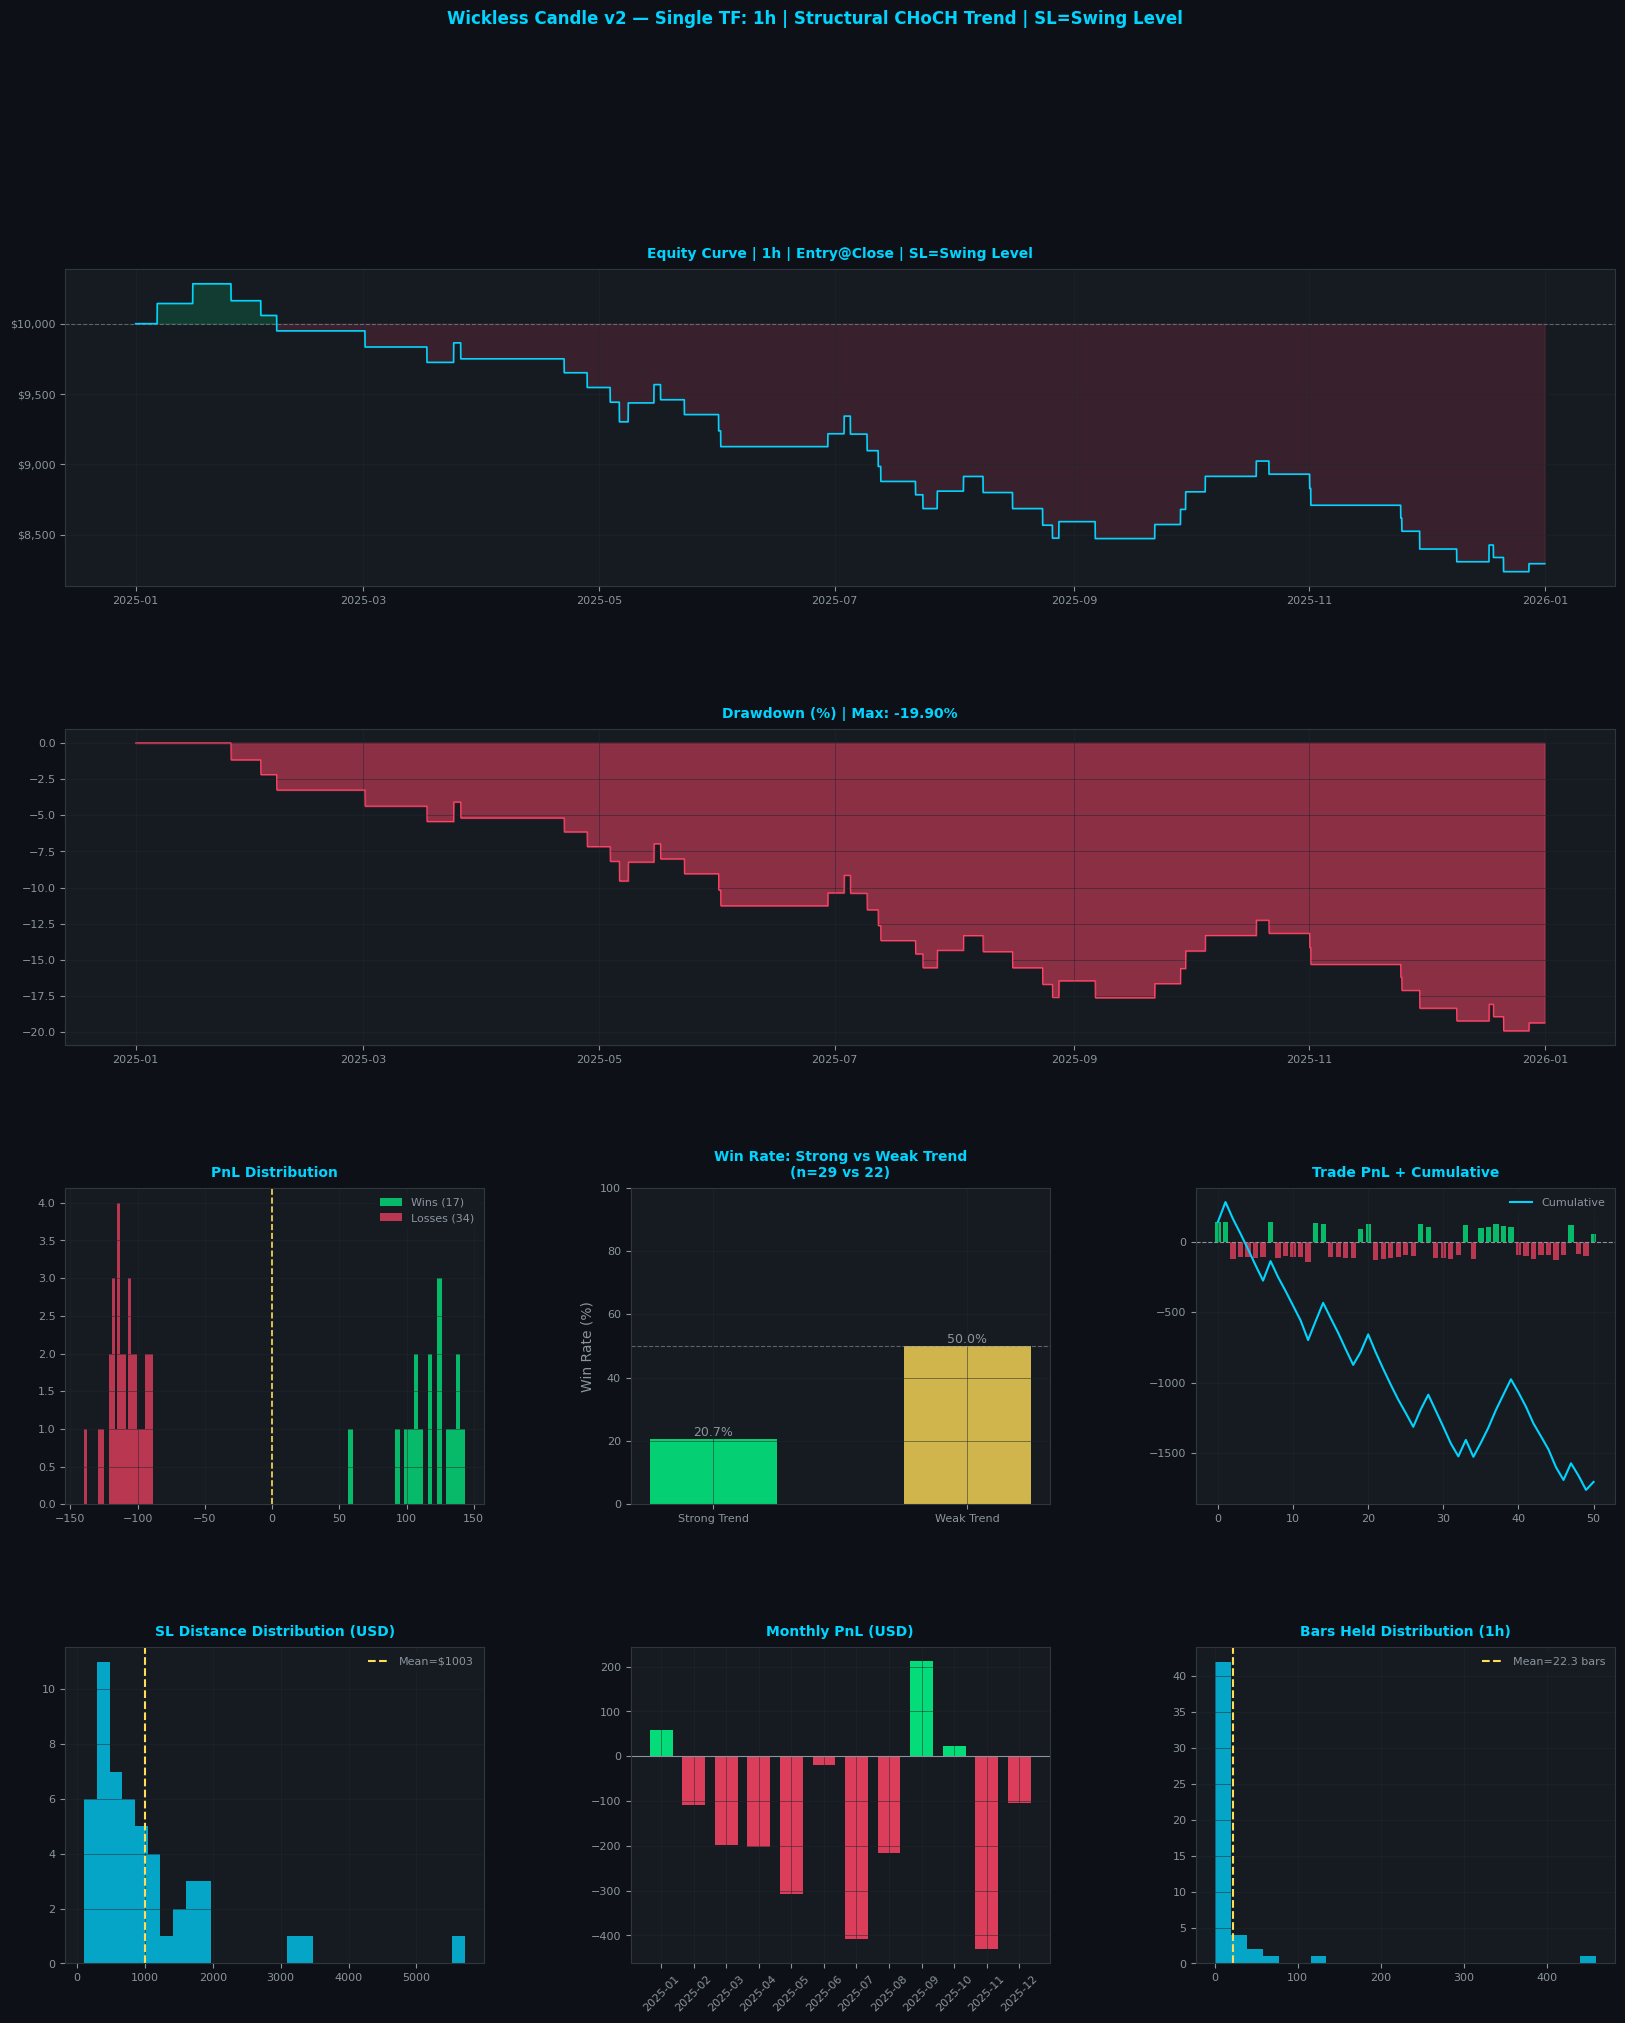

📊 Saved to wickless_v2_report.png


In [90]:
if not trades:
    print("No trades to visualize.")
else:
    fig = plt.figure(figsize=(20, 22))
    fig.patch.set_facecolor("#0d1117")
    gs  = fig.add_gridspec(4, 3, hspace=0.45, wspace=0.35)

    CYAN  = "#00d4ff"; GREEN = "#00ff88"; RED = "#ff4466"
    YELLOW= "#ffdd57"; GRAY  = "#8b949e"; PANEL = "#161b22"

    def style_ax(ax, title):
        ax.set_facecolor(PANEL)
        ax.tick_params(colors=GRAY, labelsize=8)
        ax.set_title(title, color=CYAN, fontsize=10, fontweight="bold", pad=8)
        for sp in ax.spines.values(): sp.set_edgecolor("#30363d")
        ax.grid(True, color="#21262d", linewidth=0.5, alpha=0.7)

    # ── 1. Equity curve ───────────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, :])
    ec  = equity_curve.dropna()
    ax1.plot(ec.index, ec.values, color=CYAN, linewidth=1.2, zorder=3)
    ax1.fill_between(ec.index, INITIAL_CAPITAL, ec.values,
                     where=ec.values >= INITIAL_CAPITAL, alpha=0.15, color=GREEN)
    ax1.fill_between(ec.index, INITIAL_CAPITAL, ec.values,
                     where=ec.values < INITIAL_CAPITAL,  alpha=0.15, color=RED)
    ax1.axhline(INITIAL_CAPITAL, color=GRAY, linewidth=0.8, linestyle="--", alpha=0.6)
    style_ax(ax1, f"Equity Curve | {TIMEFRAME} | Entry@Close | SL=Swing Level")
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"${x:,.0f}"))

    # ── 2. Drawdown ────────────────────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[1, :])
    dd  = (equity_curve - equity_curve.cummax()) / equity_curve.cummax() * 100
    ax2.fill_between(dd.index, dd.values, 0, color=RED, alpha=0.5)
    ax2.plot(dd.index, dd.values, color=RED, linewidth=0.8)
    style_ax(ax2, f"Drawdown (%) | Max: {dd.min():.2f}%")

    # ── 3. PnL distribution ────────────────────────────────────────────────────
    ax3 = fig.add_subplot(gs[2, 0])
    w_pnl = [t["pnl_usd"] for t in trades if t["result"]=="WIN"]
    l_pnl = [t["pnl_usd"] for t in trades if t["result"]=="LOSS"]
    if w_pnl: ax3.hist(w_pnl, bins=25, color=GREEN, alpha=0.7, label=f"Wins ({len(w_pnl)})")
    if l_pnl: ax3.hist(l_pnl, bins=25, color=RED,   alpha=0.7, label=f"Losses ({len(l_pnl)})")
    ax3.axvline(0, color=YELLOW, linewidth=1.2, linestyle="--")
    ax3.legend(fontsize=8, facecolor=PANEL, edgecolor="none", labelcolor=GRAY)
    style_ax(ax3, "PnL Distribution")

    # ── 4. Win/Loss by trend strength ─────────────────────────────────────────
    ax4 = fig.add_subplot(gs[2, 1])
    categories = ["Strong Trend", "Weak Trend"]
    strong = [t for t in trades if not t["weak_trend"]]
    weak   = [t for t in trades if t["weak_trend"]]
    wr_s   = len([t for t in strong if t["result"]=="WIN"])/len(strong)*100 if strong else 0
    wr_w   = len([t for t in weak   if t["result"]=="WIN"])/len(weak)*100   if weak   else 0
    bars   = ax4.bar(categories, [wr_s, wr_w], color=[GREEN, YELLOW], alpha=0.8, width=0.5)
    ax4.axhline(50, color=GRAY, linewidth=0.8, linestyle="--", alpha=0.6)
    for bar_obj, val in zip(bars, [wr_s, wr_w]):
        ax4.text(bar_obj.get_x()+bar_obj.get_width()/2, bar_obj.get_height()+1,
                 f"{val:.1f}%", ha="center", color=GRAY, fontsize=9)
    style_ax(ax4, f"Win Rate: Strong vs Weak Trend\n(n={len(strong)} vs {len(weak)})")
    ax4.set_ylabel("Win Rate (%)", color=GRAY)
    ax4.set_ylim(0, 100)

    # ── 5. Cumulative PnL per trade ───────────────────────────────────────────
    ax5 = fig.add_subplot(gs[2, 2])
    cum_pnl = np.cumsum([t["pnl_usd"] for t in trades])
    colors  = [GREEN if t["pnl_usd"] > 0 else RED for t in trades]
    ax5.bar(range(len(trades)), [t["pnl_usd"] for t in trades], color=colors, alpha=0.7, width=0.7)
    ax5.plot(range(len(trades)), cum_pnl, color=CYAN, linewidth=1.5, label="Cumulative")
    ax5.axhline(0, color=GRAY, linewidth=0.8, linestyle="--")
    ax5.legend(fontsize=8, facecolor=PANEL, edgecolor="none", labelcolor=GRAY)
    style_ax(ax5, "Trade PnL + Cumulative")

    # ── 6. SL distance distribution ───────────────────────────────────────────
    ax6 = fig.add_subplot(gs[3, 0])
    sl_dists = [t["sl_distance"] for t in trades]
    ax6.hist(sl_dists, bins=30, color=CYAN, alpha=0.75)
    ax6.axvline(np.mean(sl_dists), color=YELLOW, linewidth=1.5, linestyle="--",
                label=f"Mean=${np.mean(sl_dists):.0f}")
    ax6.legend(fontsize=8, facecolor=PANEL, edgecolor="none", labelcolor=GRAY)
    style_ax(ax6, "SL Distance Distribution (USD)")

    # ── 7. Monthly PnL ────────────────────────────────────────────────────────
    ax7 = fig.add_subplot(gs[3, 1])
    tdf = pd.DataFrame(trades)
    tdf["entry_time"] = pd.to_datetime(tdf["entry_time"], utc=True)
    monthly = tdf.groupby(tdf["entry_time"].dt.to_period("M"))["pnl_usd"].sum()
    bc = [GREEN if v >= 0 else RED for v in monthly.values]
    ax7.bar(range(len(monthly)), monthly.values, color=bc, alpha=0.85, width=0.7)
    ax7.set_xticks(range(len(monthly)))
    ax7.set_xticklabels([str(p) for p in monthly.index], rotation=45, fontsize=7, color=GRAY)
    ax7.axhline(0, color=GRAY, linewidth=0.8)
    style_ax(ax7, "Monthly PnL (USD)")

    # ── 8. Bars held ──────────────────────────────────────────────────────────
    ax8 = fig.add_subplot(gs[3, 2])
    bh = [t["bars_held"] for t in trades]
    ax8.hist(bh, bins=min(40, len(set(bh))), color=CYAN, alpha=0.75)
    ax8.axvline(np.mean(bh), color=YELLOW, linewidth=1.5, linestyle="--",
                label=f"Mean={np.mean(bh):.1f} bars")
    ax8.legend(fontsize=8, facecolor=PANEL, edgecolor="none", labelcolor=GRAY)
    style_ax(ax8, f"Bars Held Distribution ({TIMEFRAME})")

    plt.suptitle(
        f"Wickless Candle v2 — Single TF: {TIMEFRAME} | Structural CHoCH Trend | SL=Swing Level",
        color=CYAN, fontsize=12, fontweight="bold", y=0.998
    )
    plt.savefig("wickless_v2_report.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
    plt.show()
    print("📊 Saved to wickless_v2_report.png")

---
## Cell 10 — Structural Chart (Trend + Signals)

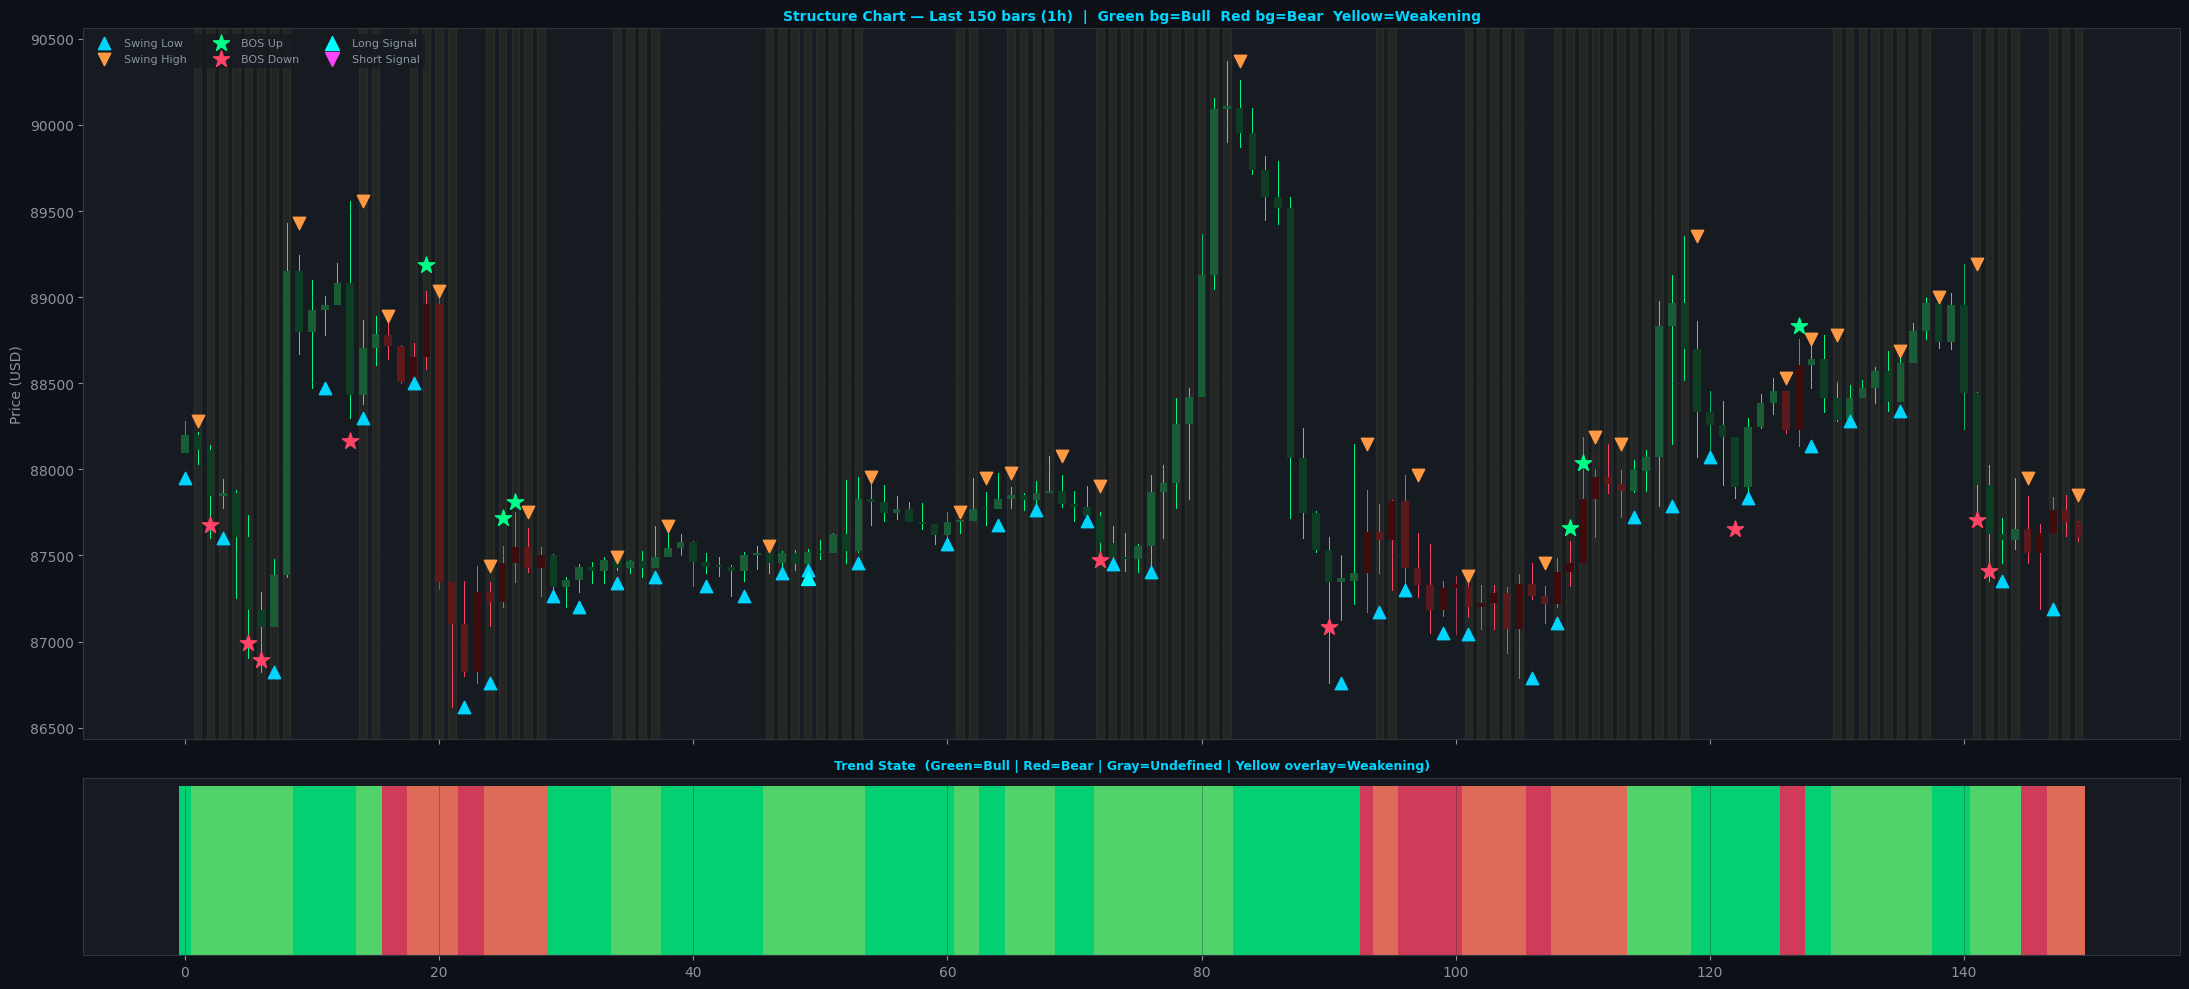

📊 Saved to wickless_v2_structure.png


In [91]:
# ══════════════════════════════════════════════════════════════════════════════
#  Plot the last N bars with:
#  - Candlesticks coloured by trend state
#  - Swing highs/lows marked
#  - Shaved bottom/top signals marked
#  - BOS events marked
#  - Trend weakening zones shaded
# ══════════════════════════════════════════════════════════════════════════════

PLOT_LAST_N = 150

sample = df.tail(PLOT_LAST_N).copy().reset_index()
n_s = len(sample)

fig, axes = plt.subplots(2, 1, figsize=(22, 10),
                         gridspec_kw={"height_ratios":[4,1]}, sharex=True)
fig.patch.set_facecolor("#0d1117")
ax_c, ax_trend = axes

for ax in axes:
    ax.set_facecolor("#161b22")
    ax.tick_params(colors="#8b949e")
    ax.grid(True, color="#21262d", linewidth=0.4, alpha=0.6)
    for sp in ax.spines.values(): sp.set_edgecolor("#30363d")

BW = 0.6
for i, row in sample.iterrows():
    trend_val = row["trend"]
    is_bull_candle = row["Close"] >= row["Open"]

    # Candle body colour by trend state
    if trend_val == 1:
        body_color = "#1a5c35" if is_bull_candle else "#0d3d22"
    elif trend_val == -1:
        body_color = "#5c1a1a" if not is_bull_candle else "#3d0d0d"
    else:
        body_color = "#2a2a2a"

    wick_color = "#00ff88" if trend_val == 1 else ("#ff4466" if trend_val == -1 else "#555555")

    body_bot = min(row["Open"], row["Close"])
    body_top = max(row["Open"], row["Close"])
    ax_c.add_patch(mpatches.FancyBboxPatch(
        (i-BW/2, body_bot), BW, max(body_top-body_bot, row["atr"]*0.05),
        boxstyle="square,pad=0", facecolor=body_color, linewidth=0, zorder=2))
    ax_c.plot([i,i],[row["Low"],body_bot],  color=wick_color, lw=0.7, zorder=1)
    ax_c.plot([i,i],[body_top,row["High"]], color=wick_color, lw=0.7, zorder=1)

    # Trend weakening shading
    if row["trend_weakening"]:
        ax_c.axvspan(i-BW/2, i+BW/2, color="#ffdd57", alpha=0.06, zorder=0)

# Swing lows
sw_l = sample[sample["sl_confirmed"]]
ax_c.scatter(sw_l.index, sw_l["sl_price"], marker="^", color="#00d4ff",
             s=80, zorder=6, label="Swing Low")

# Swing highs
sw_h = sample[sample["sh_confirmed"]]
ax_c.scatter(sw_h.index, sw_h["sh_price"], marker="v", color="#ff9944",
             s=80, zorder=6, label="Swing High")

# BOS events
bos_u = sample[sample["bos_up"]]
bos_d = sample[sample["bos_down"]]
ax_c.scatter(bos_u.index, bos_u["Close"]+bos_u["atr"]*0.5,
             marker="*", color="#00ff88", s=150, zorder=7, label="BOS Up")
ax_c.scatter(bos_d.index, bos_d["Close"]-bos_d["atr"]*0.5,
             marker="*", color="#ff4466", s=150, zorder=7, label="BOS Down")

# Signal candles
sig_long  = sample[sample["raw_signal"] == 1]
sig_short = sample[sample["raw_signal"] == -1]
ax_c.scatter(sig_long.index,  sig_long["Low"]  - sig_long["atr"]*0.4,
             marker="^", color="#00ffff", s=100, zorder=8, label="Long Signal")
ax_c.scatter(sig_short.index, sig_short["High"] + sig_short["atr"]*0.4,
             marker="v", color="#ff44ff", s=100, zorder=8, label="Short Signal")

ax_c.legend(fontsize=8, facecolor="#161b22", edgecolor="none",
            labelcolor="#8b949e", loc="upper left", ncol=3)
ax_c.set_title(f"Structure Chart — Last {PLOT_LAST_N} bars ({TIMEFRAME})  |  "
               f"Green bg=Bull  Red bg=Bear  Yellow=Weakening",
               color="#00d4ff", fontsize=10, fontweight="bold")
ax_c.set_ylabel("Price (USD)", color="#8b949e")

# Trend state panel
trend_colors = {1:"#00ff88", -1:"#ff4466", 0:"#444444"}
t_vals = sample["trend"].values
for i in range(len(sample)):
    ax_trend.bar(i, 1, color=trend_colors.get(int(t_vals[i]),"#444444"), alpha=0.8, width=1.0)
    if sample.iloc[i]["trend_weakening"]:
        ax_trend.bar(i, 1, color="#ffdd57", alpha=0.3, width=1.0)

ax_trend.set_yticks([])
ax_trend.set_title("Trend State  (Green=Bull | Red=Bear | Gray=Undefined | Yellow overlay=Weakening)",
                   color="#00d4ff", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("wickless_v2_structure.png", dpi=130, bbox_inches="tight", facecolor="#0d1117")
plt.show()
print("📊 Saved to wickless_v2_structure.png")

---
## Cell 11 — Weak vs Strong Trend Signal Analysis

In [92]:
if trades_df is not None and len(trades_df) > 0:
    print("=== STRONG TREND TRADES ===")
    strong = trades_df[trades_df["weak_trend"]==False]
    weak   = trades_df[trades_df["weak_trend"]==True]

    for label, subset in [("STRONG", strong), ("WEAK", weak)]:
        if len(subset) == 0:
            print(f"  {label}: no trades")
            continue
        w = subset[subset["result"]=="WIN"]
        l = subset[subset["result"]=="LOSS"]
        wr_ = len(w)/len(subset)*100
        pf_ = w["pnl_usd"].sum()/abs(l["pnl_usd"].sum()) if len(l)>0 and l["pnl_usd"].sum()!=0 else np.inf
        exp_ = subset["pnl_usd"].mean()
        print(f"  {label:6s}: n={len(subset):3d}  WR={wr_:.1f}%  PF={pf_:.3f}  "
              f"AvgPnL=${exp_:.2f}  TotalPnL=${subset['pnl_usd'].sum():.2f}")

    print()
    print("=== LONG vs SHORT ===")
    for direction in ["LONG", "SHORT"]:
        subset = trades_df[trades_df["direction"]==direction]
        if len(subset) == 0: continue
        w = subset[subset["result"]=="WIN"]
        l = subset[subset["result"]=="LOSS"]
        wr_ = len(w)/len(subset)*100
        exp_ = subset["pnl_usd"].mean()
        print(f"  {direction:5s}: n={len(subset):3d}  WR={wr_:.1f}%  AvgPnL=${exp_:.2f}  "
              f"TotalPnL=${subset['pnl_usd'].sum():.2f}")

    print()
    print("=== SL DISTANCE STATS ===")
    print(f"  Mean SL distance : ${trades_df['sl_distance'].mean():.2f}")
    print(f"  Median SL dist   : ${trades_df['sl_distance'].median():.2f}")
    print(f"  Min SL distance  : ${trades_df['sl_distance'].min():.2f}")
    print(f"  Max SL distance  : ${trades_df['sl_distance'].max():.2f}")
    print(f"  Mean ATR (entry) : ${df['atr'].mean():.2f}")
    print(f"  Mean SL / ATR    : {trades_df['sl_distance'].mean()/df['atr'].mean():.2f}x")

=== STRONG TREND TRADES ===
  STRONG: n= 29  WR=20.7%  PF=0.281  AvgPnL=$-62.66  TotalPnL=$-1817.10
  WEAK  : n= 22  WR=50.0%  PF=1.096  AvgPnL=$5.06  TotalPnL=$111.28

=== LONG vs SHORT ===
  LONG : n= 29  WR=51.7%  AvgPnL=$8.71  TotalPnL=$252.47
  SHORT: n= 22  WR=9.1%  AvgPnL=$-89.01  TotalPnL=$-1958.29

=== SL DISTANCE STATS ===
  Mean SL distance : $1002.54
  Median SL dist   : $775.60
  Min SL distance  : $107.90
  Max SL distance  : $5715.70
  Mean ATR (entry) : $635.03
  Mean SL / ATR    : 1.58x


---
## Cell 12 — Summary

In [93]:
print("═"*62)
print("  🏁  RUN SUMMARY — Wickless Candle v2 (Single Timeframe)")
print("═"*62)
print(f"  Timeframe       : {TIMEFRAME}")
print(f"  Period          : {df.index[0]} → {df.index[-1]}")
print(f"  Wick tolerance  : {WICK_TOLERANCE} USD")
print(f"  Displacement    : {'ON @ '+str(DISPLACEMENT_THRESHOLD) if USE_DISPLACEMENT else 'OFF'}")
print(f"  CHoCH confirm   : {CHOCH_CONFIRM_BARS} bars")
print(f"  Trend strength  : {'ON' if ENABLE_TREND_STRENGTH else 'OFF'}")
print(f"  SL method       : Nearest swing level (fallback ATR×{ATR_SL_FALLBACK_MULT})")
print(f"  RR              : {RR_RATIO}:1  |  Trailing: {USE_TRAILING_STOP}")
print(f"  Risk per trade  : {RISK_PER_TRADE_PCT}%")
print("─"*62)
if metrics:
    for k in ["Total Trades","Win Rate (%)","Profit Factor","Expectancy (USD)",
              "Total Return (%)","Max Drawdown (%)","Sharpe Ratio","Final Capital (USD)",
              "Weak Trend Trades","Weak WR (%)","Strong WR (%)"]:
        print(f"  {k:<28} {str(metrics[k]):>12}")
print("═"*62)
print("""
💡 NEXT EXPERIMENTS:
  1. Tune CHOCH_CONFIRM_BARS (try 5, 8, 15, 20)
  2. Tune WICK_TOLERANCE (try 1, 2, 5 USD)
  3. Enable USE_DISPLACEMENT with THRESHOLD 0.75–0.90
  4. Try TIMEFRAME = '1h' or '30m'
  5. Compare STRONG vs WEAK trend trade results (Cell 11)
  6. Try USE_TRAILING_STOP = True
  7. Try RR_RATIO = 1.5 or 2.5
""")

══════════════════════════════════════════════════════════════
  🏁  RUN SUMMARY — Wickless Candle v2 (Single Timeframe)
══════════════════════════════════════════════════════════════
  Timeframe       : 1h
  Period          : 2025-01-01 00:00:00+00:00 → 2025-12-31 23:00:00+00:00
  Wick tolerance  : 0.0 USD
  Displacement    : ON @ 0.8
  CHoCH confirm   : 5 bars
  Trend strength  : ON
  SL method       : Nearest swing level (fallback ATR×1.5)
  RR              : 1.5:1  |  Trailing: False
  Risk per trade  : 1.0%
──────────────────────────────────────────────────────────────
  Total Trades                           51
  Win Rate (%)                        33.33
  Profit Factor                      0.5367
  Expectancy (USD)                   -33.45
  Total Return (%)                   -17.06
  Max Drawdown (%)                    -19.9
  Sharpe Ratio                       -3.472
  Final Capital (USD)                8294.2
  Weak Trend Trades                      22
  Weak WR (%)           